In [37]:
from __future__ import annotations

import json
from pathlib import Path

from u_flora.client_profile.profile_generator import generate_device_profiles

In [38]:
CUR_IDR = Path.cwd()
NETWORK_TRACE = CUR_IDR / "network" / "trace.json"
COMPUTE_TRACE = CUR_IDR / "computation" / "trace.json"
OUTPUT_PATH = CUR_IDR / "combined.json"

NUM_PROFILES = 10000
SEED = 42
CORRELATED_RATIO = 0.7

In [39]:
profiles, t_min_ms = generate_device_profiles(
    num_profiles=NUM_PROFILES,
    network_trace_path=NETWORK_TRACE,
    compute_trace_path=COMPUTE_TRACE,
    seed=SEED,
    correlated_ratio=CORRELATED_RATIO,
)

profile_dicts = [
    {
        "computation_latency_ms": p.computation_latency_ms,
        "download_kbps": p.download_kbps,
        "upload_kbps": p.upload_kbps,
        "latency_ms": p.latency_ms,
        "jitter_ms": p.jitter_ms,
        "network_type": p.network_type,
    }
    for p in profiles
]

payload = {
    "metadata": {
        "t_min_ms": t_min_ms,
        "num_profiles": len(profile_dicts),
        "seed": SEED,
        "correlated_ratio": CORRELATED_RATIO,
    },
    "profiles": profile_dicts,
}

OUTPUT_PATH.write_text(json.dumps(payload, indent=2))
print(f"Saved {len(profile_dicts)} combined profiles to {OUTPUT_PATH}")
print(f"t_min_ms = {t_min_ms:.4f}")

Saved 10000 combined profiles to d:\COOLYEAH\SKRIPSI\u-flora\traces\combined.json
t_min_ms = 12.0000


In [40]:
durations = sorted([p["computation_latency_ms"] for p in profile_dicts])
print("Computation latency percentiles (ms/sample):")
for pct in [10, 25, 50, 75, 90]:
    idx = min(int(len(durations) * pct / 100), len(durations) - 1)
    print(f"P{pct}: {durations[idx]:.2f}")

Computation latency percentiles (ms/sample):
P10: 83.57
P25: 117.81
P50: 177.38
P75: 292.80
P90: 466.91


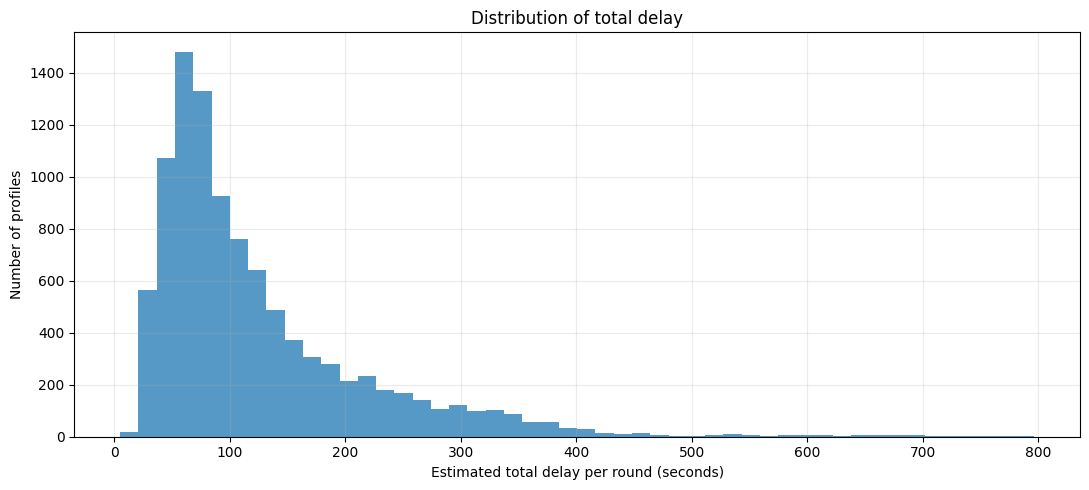

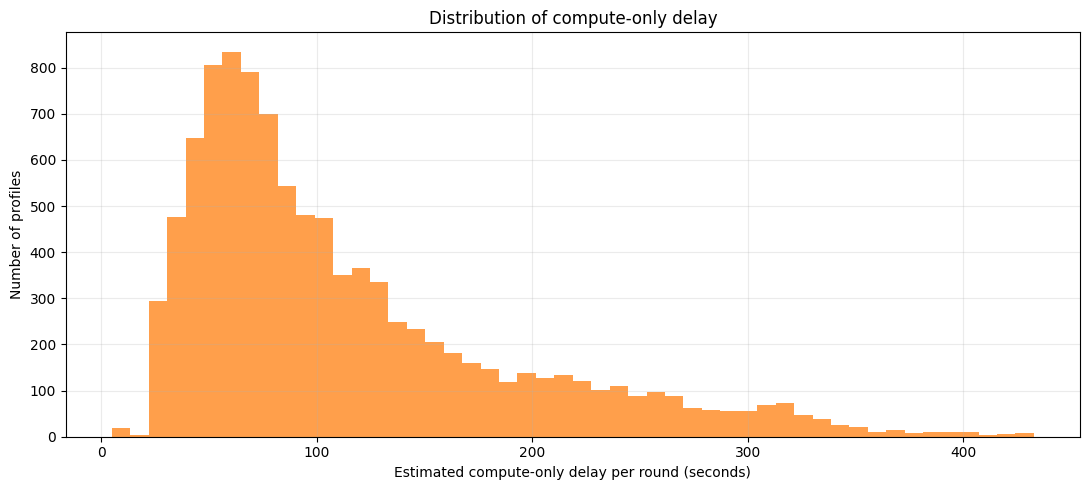

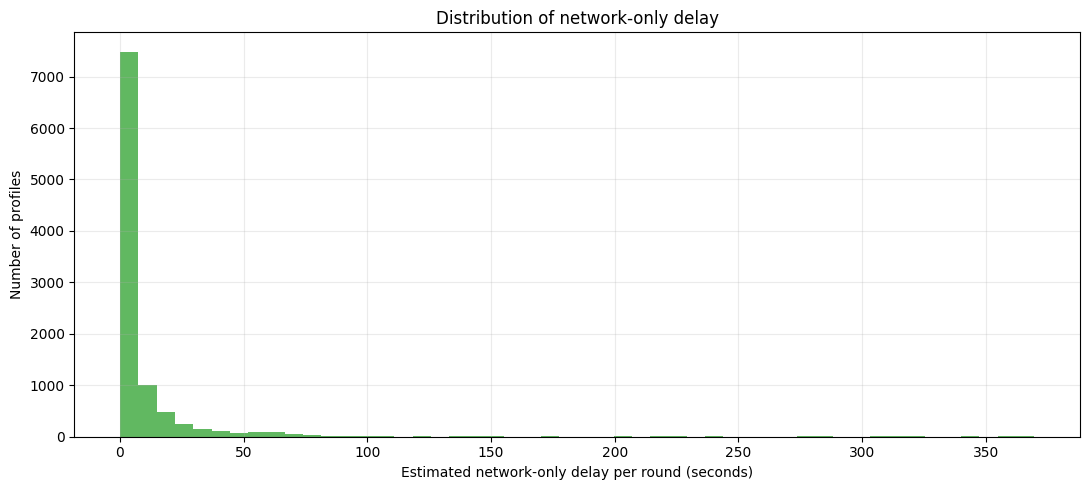

Total delay median: 92.68s
Compute delay median: 88.69s
Network delay median: 1.94s


In [ ]:
import matplotlib.pyplot as plt

# Delay estimation config (match setup.py assumptions)
AVG_NUM_SAMPLES = 1300
MODEL_SIZE_KB = 6607.0 
# ModernBERT; r=8; target_modules=["Wqkv", "attn.Wo"]
# Trainable: 812,546 / 150,418,948
# Assumed payload size = trainable params * 4 bytes/param / 1024 bytes/KB


compute_delays_s = [
    p["computation_latency_ms"] * AVG_NUM_SAMPLES / 1000.0
    for p in profile_dicts
]
network_delays_s = [
    (MODEL_SIZE_KB / max(1.0, p["download_kbps"]))
    + (MODEL_SIZE_KB / max(1.0, p["upload_kbps"]))
    + (p["latency_ms"] / 1000.0)
    for p in profile_dicts
]
total_delays_s = [c + n for c, n in zip(compute_delays_s, network_delays_s)]

bins = 50

plt.figure(figsize=(11, 5))
plt.hist(total_delays_s, bins=bins, alpha=0.75, color="tab:blue")
plt.xlabel("Estimated total delay per round (seconds)")
plt.ylabel("Number of profiles")
plt.title("Distribution of total delay")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 5))
plt.hist(compute_delays_s, bins=bins, alpha=0.75, color="tab:orange")
plt.xlabel("Estimated compute-only delay per round (seconds)")
plt.ylabel("Number of profiles")
plt.title("Distribution of compute-only delay")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 5))
plt.hist(network_delays_s, bins=bins, alpha=0.75, color="tab:green")
plt.xlabel("Estimated network-only delay per round (seconds)")
plt.ylabel("Number of profiles")
plt.title("Distribution of network-only delay")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print(f"Total delay median: {sorted(total_delays_s)[len(total_delays_s)//2]:.2f}s")
print(f"Compute delay median: {sorted(compute_delays_s)[len(compute_delays_s)//2]:.2f}s")
print(f"Network delay median: {sorted(network_delays_s)[len(network_delays_s)//2]:.2f}s")